# 03 – Baseline Time Series Forecasting

In this notebook we build and evaluate simple baseline forecasting models for hourly electricity demand, using the feature-engineered dataset created in Notebook 02.

## 1. Imports and configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load feature-engineered dataset

In [2]:
data_path = "../data/processed/electricity_hourly_features.csv"

df = pd.read_csv(
    data_path,
    parse_dates=["timestamp"],
    index_col="timestamp"
)

df.head()

,load_mw,hour,dayofweek,day,month,is_weekend,lag_1,lag_2,lag_3,lag_6,...,lag_48,lag_168,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,rolling_mean_24,rolling_std_24
timestamp,,,,,,,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,8,1,0,31187.0,33579.0,35997.0,39581.0,...,27100.0,30393.0,33587.666667,2405.011712,36150.166667,3243.473719,36247.583333,2390.029002,33452.583333,4559.767709
2002-01-08 02:00:00,28670.0,2,1,8,1,0,29445.0,31187.0,33579.0,38780.0,...,26097.0,29265.0,31403.666667,2075.499297,34460.833333,3705.837796,35718.833333,3097.586504,33560.208333,4425.965952
2002-01-08 03:00:00,28375.0,3,1,8,1,0,28670.0,29445.0,31187.0,37777.0,...,25793.0,28357.0,29767.333333,1289.087403,32775.833333,3647.173394,35141.833333,3707.741087,33672.458333,4256.159403
2002-01-08 04:00:00,28542.0,4,1,8,1,0,28375.0,28670.0,29445.0,35997.0,...,25657.0,27899.0,28830.000000,552.652694,31208.833333,3037.502291,34545.833333,4184.385169,33786.375000,4064.104959
2002-01-08 05:00:00,29261.0,5,1,8,1,0,28542.0,28375.0,28670.0,33579.0,...,25778.0,28057.0,28529.000000,147.929037,29966.333333,2052.058641,33966.916667,4509.934377,33906.208333,3851.076461


## 3. Train / test split

We split the data chronologically to avoid data leakage.
The last portion of the series is used as test set.


In [3]:
test_size = int(len(df) * 0.2)

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (115532, 22)
Test shape: (28882, 22)


## 4. Baseline model 1 – Naive forecast

The naive baseline predicts the last observed value as the forecast
for all future time steps.


In [4]:
last_value = train["load_mw"].iloc[-1]
naive_forecast = np.full(shape=len(test), fill_value=last_value)

## 5. Baseline model 2 – Seasonal naive (24h lag)

This baseline uses the value observed 24 hours earlier as prediction.

In [5]:
seasonal_lag = 24

seasonal_forecast = test["load_mw"].shift(seasonal_lag)

# Align and drop NaNs
seasonal_forecast = seasonal_forecast.dropna()
seasonal_test = test.loc[seasonal_forecast.index]

## 6. Evaluation metrics

We evaluate forecasts using MAE and RMSE.

In [6]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse
    }

## 7. Baseline evaluation

In [7]:
results = []

# Naive
results.append(
    evaluate_forecast(
        test["load_mw"],
        naive_forecast,
        "Naive (last value)"
    )
)

# Seasonal naive
results.append(
    evaluate_forecast(
        seasonal_test["load_mw"],
        seasonal_forecast,
        "Seasonal naive (24h)"
    )
)

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE
0,Naive (last value),9931.538519,11843.182144
1,Seasonal naive (24h),2187.281586,3011.654315


## 8. Visual comparison of forecasts

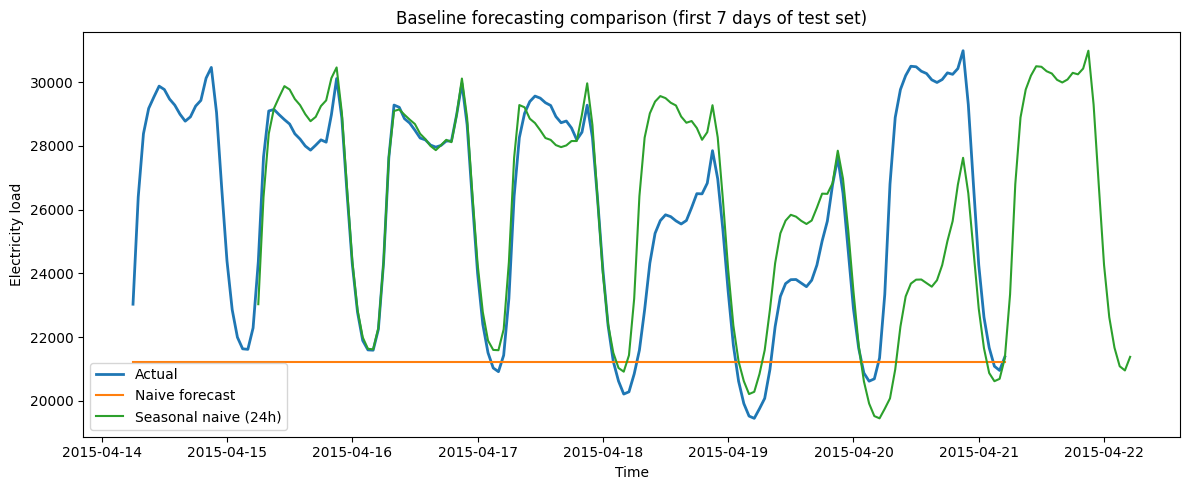

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(test.index[:168], test["load_mw"][:168], label="Actual", linewidth=2)
plt.plot(test.index[:168], naive_forecast[:168], label="Naive forecast")
plt.plot(
    seasonal_test.index[:168],
    seasonal_forecast[:168],
    label="Seasonal naive (24h)"
)

plt.title("Baseline forecasting comparison (first 7 days of test set)")
plt.xlabel("Time")
plt.ylabel("Electricity load")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary

- Simple baselines provide a useful reference level for forecasting performance.
- Seasonal naive forecasts capture daily patterns better than a constant prediction.
- In the next notebook we will introduce a first statistical or machine learning model
  to improve upon these baselines.